In [16]:
import uproot
import numpy as np
import awkward as ak
import os
import sys
from glob import glob
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit
import pandas as pd

In [17]:
def read_file(filename):
    file = uproot.open(filename)["pulse"].arrays()
    return file

def gaussian(x, A, mean, std):
    return A * np.exp(-1*(1/2)*((x-mean)/std)**2)

def timing_resolution(filename):
    data = read_file(f"{path}/{filename}")
    os.system(f"mkdir -p plots")
    os.system(f"mkdir ./plots/{filename}/")
    # output_file = open(f"./plots/{filename}/output_params.csv", "w")
    signal_cut_efficiency = []
    timing_resolution = []
    chi_squared = []
    # branches = data[0].fields
    branches = ['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']
    quadratic_fit = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80]
    print(branches)
    trigger = 0
    signal = 3
    n_bins = 60
    n_rows = 2
    for b, branch in enumerate(branches):
        fig, ax = plt.subplots(1, n_rows, figsize = (10*n_rows, 7))
        cut = (data[branch][:, trigger] < 95) # & (data[branch][:, signal] < data[branch][:, signal] + 10)
        signal_cut_efficiency.append(np.sum(cut)/len(cut))
        ax[0].hist2d(np.array(data[branch][:, signal][cut]), np.array(data[branch][:, trigger][cut]), bins=n_bins, norm=LogNorm())
        ax[0].set_ylabel("Trigger TOA [ns]")
        ax[0].set_xlabel("Signal TOA [ns]")
        ax[0].set_title(branch)
        deltaT = np.array(data[branch][:, signal][cut])-np.array(data[branch][:, trigger][cut])
        mean = np.mean(deltaT)
        std = np.std(deltaT)
        std_spacing = 2
        histo_num = ax[1].hist(deltaT, bins=n_bins, histtype="step", range=(mean-std_spacing*std, mean+std_spacing*std), linewidth=2)
        x_axis = histo_num[1][0:-1]
        y_axis = histo_num[0]
        p0 = (mean, mean, std)
        popt, pcov = curve_fit(gaussian, x_axis, y_axis, p0=p0)
        fit_amp = np.round(popt[0],2)
        fit_mean = np.round(popt[1],2)
        fit_sigma = np.abs(np.round(popt[2]*1000,2))
        print(p0)
        print(popt)
        timing_resolution.append(fit_sigma)
        chi_sq = ((y_axis - gaussian(x_axis, *popt))**2)/y_axis
        print(f"Difference {quadratic_fit[b]}: ", (y_axis - gaussian(x_axis, *popt))**2)
        print(f"Ratio {quadratic_fit[b]}: ", chi_sq)
        chi_squared.append(np.sum(chi_sq[np.isfinite(chi_sq)])/n_bins)
        print(f"Chi squared {quadratic_fit[b]}:", np.sum(chi_sq[np.isfinite(chi_sq)]))
        ax[1].plot(x_axis, gaussian(x_axis, *popt), 'r-', label=f'Fit: A={fit_amp}, mean={fit_mean} ns, sigma={fit_sigma} ps')
        ax[1].set_ylabel("Events")
        ax[1].set_xlabel("ΔT [ns]")
        ax[1].set_title(branch)
        ax[1].legend()
        fig.savefig(f"./plots/{filename}/{branch}.png")
    print("chi squared", chi_squared)
    fig, ax = plt.subplots(1, 2, figsize = (20, 7))
    ax[0].set_ylabel("Resolution [ps]")
    ax[0].set_xlabel("Fit amplitude %")
    ax[0].plot(quadratic_fit, timing_resolution, linewidth=2, marker="o", label = f"Best resolution: {min(timing_resolution)} ps")
    ax[0].legend()
    ax[1].set_ylabel("Chi^2/nof")
    ax[1].set_xlabel("Fit amplitude %")
    ax[1].plot(quadratic_fit, chi_squared, linewidth=2, marker="o", label = f"Best fit accuracy, χ²: {min(chi_squared)}")
    ax[1].legend()
    df = pd.DataFrame({"signal_cut_efficiency":signal_cut_efficiency, "timing_resolution":timing_resolution})
    os.system(f"rm ./plots/{filename}/output_params.csv")
    df.to_csv(f"./plots/{filename}/output_params.csv")
    fig.savefig(f"./plots/{filename}/timing_resolution.png")


In [18]:
path = "/home/cmspractice/FCFD-Project/FCFD-Laser-AANL/DAQ/processed"
path = "/home/aram/FirstLGADData/processed"
path = "../../Processed_data"
filename = "run_x-3000_y-24000_z-4000_TR1_N25000_LGAD_processed.root"
filename = "proc_F_AC100W80_strip3mm_bv116_mcp4400_trigCh4_Ch8_collimatedTwice_3days.root"
file_path = f"{path}/{filename}" # os.listdir(path)

In [19]:
data = read_file(file_path)
branches = data[0].fields
print(branches)

['i_evt', 'channel', 'time', 'baseline', 'baseline_RMS', 'noise', 'amp', 't_peak', 'integral', 'intfull', 'risetime', 'decaytime', 'LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_45', 'LP2_50', 'LP2_55', 'LP2_60', 'LP2_65', 'LP2_70', 'LP2_75', 'LP2_80', 'LP2_85', 'LP2_90', 'LP2_95', 'LP2_100', 'LP2_10mV', 'LP2_20mV', 'LP2_30mV', 'LP2_50mV', 'LP2_70mV', 'LP2_90mV', 'LP2_100mV', 'LP2_120mV', 'LP2_140mV', 'LP2_160mV', 'LP2_180mV', 'LP2_200mV', 'linear_RE_5', 'linear_RE_10', 'linear_RE_15', 'linear_RE_20', 'linear_RE_25', 'linear_RE_30', 'linear_RE_35', 'linear_RE_40', 'linear_RE_45', 'linear_RE_50', 'linear_RE_55', 'linear_RE_60', 'linear_RE_65', 'linear_RE_70', 'linear_RE_75', 'linear_RE_80', 'linear_RE_85', 'linear_RE_90', 'linear_RE_95', 'linear_RE_100', 'linear_RE__10mV', 'linear_RE__20mV', 'linear_RE__30mV', 'linear_RE__50mV', 'linear_RE__70mV', 'linear_RE__90mV', 'linear_RE__100mV', 'linear_RE__120mV', 'linear_RE__140mV', 'linear_RE__160mV', 'line

In [ ]:
branches = ['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']
quadratic_fit = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80]

# branches = ['LP2_20', 'LP2_50', 'LP2_80']
# quadratic_fit = [20, 50, 80]

# branches = ['LP2_50']
# quadratic_fit = [50]

n_rows = 1
n_cols = 3
n_bins = 80
n_bins_dt = 30
fig, ax = plt.subplots(n_rows, n_cols, figsize = (7*n_cols, 5*n_rows))
for b in branches:
    cut = (data["baseline_RMS"][:,3]<3)&(data[b][:,3]<-1)&(data[b][:,7]<-1)
    T_MCP = data[b][:,7][cut]
    T_CH4 = data[b][:,3][cut]
    deltaT = T_MCP-T_CH4
    mean = np.mean(deltaT)
    std = np.std(deltaT)
    std_spacing = 2
    ax[0].hist(T_CH4, label=b, histtype="step", bins=n_bins)
    ax[1].hist(T_MCP, label=b, histtype="step", bins=n_bins)
    histo_num = ax[2].hist(deltaT, label=b, histtype="step", range=(3.8, 4.3), bins=n_bins_dt)
    # ax[1].hist(deltaT, bins=n_bins, histtype="step", range=(mean-std_spacing*std, mean+std_spacing*std), linewidth=2)
    x_axis = histo_num[1][0:-1]
    y_axis = histo_num[0]
    p0 = (mean, mean, std)
    popt, pcov = curve_fit(gaussian, x_axis, y_axis, p0=p0)
    fit_amp = np.round(popt[0],2)
    fit_mean = np.round(popt[1],2)
    fit_sigma = np.abs(np.round(popt[2]*1000,2))
    print(p0)
    print(popt)
    chi_sq = ((y_axis - gaussian(x_axis, *popt))**2)/y_axis
    # print(f"Difference {quadratic_fit[b]}: ", (y_axis - gaussian(x_axis, *popt))**2)
    # print(f"Ratio {quadratic_fit[b]}: ", chi_sq)
    # print(f"Chi squared {quadratic_fit[b]}:", np.sum(chi_sq[np.isfinite(chi_sq)]))
    ax[2].plot(x_axis, gaussian(x_axis, *popt), 'r-', label=f'Fit: A={fit_amp}, mean={fit_mean} ns, sigma={fit_sigma} ps, chi_sq={np.round(np.sum(chi_sq[np.isfinite(chi_sq)])/n_bins_dt,3)}')
    ax[2].set_ylabel("Events")
    ax[2].set_xlabel("ΔT [ns]")
    # ax[2].set_title(b)
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

In [ ]:
# branches = ['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']
quadratic_fit = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80]

# branches = ['LP2_20', 'LP2_50', 'LP2_80']
# quadratic_fit = [20, 50, 80]

# branches = ['LP2_50']
# quadratic_fit = [50]

n_rows = 1
n_cols = 3
n_bins = 80
n_bins_dt = 30
fig, ax = plt.subplots(n_rows, n_cols, figsize = (7*n_cols, 5*n_rows))
for b in quadratic_fit:
    cut = (data["baseline_RMS"][:,3]<3)&(data[f"linear_RE_{b}"][:,3]<-1)&(data[f"linear_RE_{b}"][:,7]<-1)
    T_MCP = data[f"linear_RE_{b}"][:,7][cut]
    T_CH4 = data[f"linear_RE_{b}"][:,3][cut]
    deltaT = T_MCP-T_CH4
    mean = np.mean(deltaT)
    std = np.std(deltaT)
    std_spacing = 2
    ax[0].hist(T_CH4, label=f"linear_RE_{b}", histtype="step", bins=n_bins)
    ax[1].hist(T_MCP, label=f"linear_RE_{b}", histtype="step", bins=n_bins)
    histo_num = ax[2].hist(deltaT, label=f"linear_RE_{b}", histtype="step", range=(3.8, 4.3), bins=n_bins_dt)
    # ax[1].hist(deltaT, bins=n_bins, histtype="step", range=(mean-std_spacing*std, mean+std_spacing*std), linewidth=2)
    x_axis = histo_num[1][0:-1]
    y_axis = histo_num[0]
    p0 = (mean, mean, std)
    popt, pcov = curve_fit(gaussian, x_axis, y_axis, p0=p0)
    fit_amp = np.round(popt[0],2)
    fit_mean = np.round(popt[1],2)
    fit_sigma = np.abs(np.round(popt[2]*1000,2))
    print(p0)
    print(popt)
    chi_sq = ((y_axis - gaussian(x_axis, *popt))**2)/y_axis
    # print(f"Difference {quadratic_fit[b]}: ", (y_axis - gaussian(x_axis, *popt))**2)
    # print(f"Ratio {quadratic_fit[b]}: ", chi_sq)
    # print(f"Chi squared {quadratic_fit[b]}:", np.sum(chi_sq[np.isfinite(chi_sq)]))
    ax[2].plot(x_axis, gaussian(x_axis, *popt), 'r-', label=f'Fit: A={fit_amp}, mean={fit_mean} ns, sigma={fit_sigma} ps, chi_sq={np.round(np.sum(chi_sq[np.isfinite(chi_sq)])/n_bins_dt,3)}')
    ax[2].set_ylabel("Events")
    ax[2].set_xlabel("ΔT [ns]")
    # ax[2].set_title(b)
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

In [ ]:
branches = ['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']

branches = ['LP2_20', 'LP2_50', 'LP2_80']
n_rows = 1
n_cols = 3
n_bins = 80
fig, ax = plt.subplots(n_rows, n_cols, figsize = (7*n_cols, 5*n_rows))
for b in branches:
    cut = (data["baseline_RMS"][:,3]<3)&(data[b][:,3]<-1)&(data[b][:,7]<-1)
    T_MCP = data[b][:,7][cut]
    T_CH4 = data[b][:,3][cut]
    ax[0].hist(T_CH4, label=b, histtype="step", bins=n_bins)
    ax[1].hist(T_MCP, label=b, histtype="step", bins=n_bins)
    ax[2].hist(T_MCP-T_CH4, label=b, histtype="step", bins=n_bins)
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

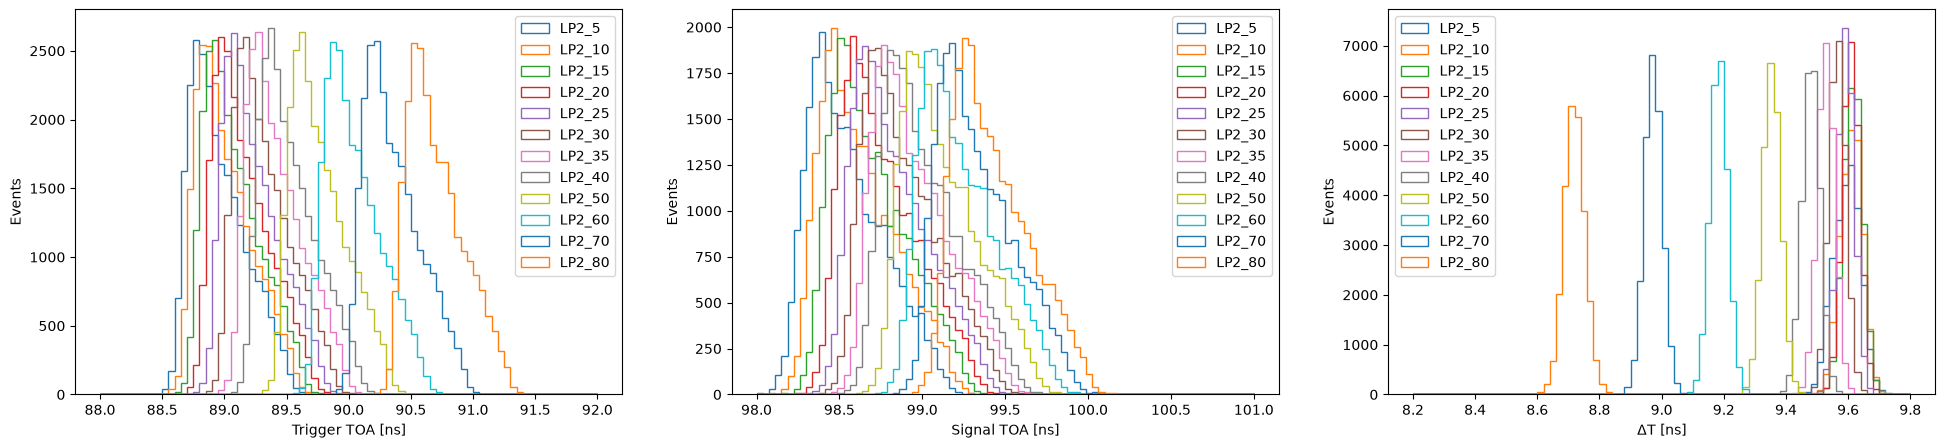

In [13]:
branches = ['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']

n_rows = 1
n_cols = 3
n_bins = 80
fig, ax = plt.subplots(n_rows, n_cols, figsize = (8*n_cols, 5*n_rows))

for b in branches:
    cut = (data[b][:,0]<95.0)
    ax[0].hist(data[b][cut][:,0], label=b, range = (88,92), histtype="step", bins=n_bins)
    ax[1].hist(data[b][cut][:,3], label=b, range = (98,101), histtype="step", bins=n_bins)
    ax[2].hist(data[b][cut][:,3]-data[b][cut][:,0], label=b, range = (8.2,9.8), histtype="step", bins=n_bins)
ax[0].set_xlabel("Trigger TOA [ns]")
ax[1].set_xlabel("Signal TOA [ns]")
ax[2].set_xlabel("ΔT [ns]")
ax[0].set_ylabel("Events")
ax[1].set_ylabel("Events")
ax[2].set_ylabel("Events")
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

In [14]:
plt.ioff()
timing_resolution(filename=filename)

mkdir: cannot create directory ‘./plots/run_x-3000_y-24000_z-4000_TR1_N25000_LGAD_processed.root/’: File exists
/tmp/ipykernel_580961/1760994040.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax[0].hist2d(np.array(data[branch][:, signal][cut]), np.array(data[branch][:, trigger][cut]), bins=n_bins, norm=LogNorm())
/tmp/ipykernel_580961/1760994040.py:32: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  deltaT = np.array(data[branch][:, signal][cut])-np.array(data[branch][:

['LP2_5', 'LP2_10', 'LP2_15', 'LP2_20', 'LP2_25', 'LP2_30', 'LP2_35', 'LP2_40', 'LP2_50', 'LP2_60', 'LP2_70', 'LP2_80']
(np.float32(9.594937), np.float32(9.594937), np.float32(0.04221188))
[6.39703285e+02 9.59591462e+00 4.50972481e-02]
Difference 5:  [ 305.4388212    19.35538999   10.11473916   97.18261427  237.81839319
 1081.59562446  917.13623068 1200.93869283 2505.87137062 3791.38932768
 1789.67041054 2534.89032749  775.19313563  258.04614145 3112.86601811
  134.53885448   41.88461316  231.37442133  207.65884359 3232.75246346
  426.93333041 4178.21246999 4562.80524142 3011.88567609 2250.81834979
 3371.48891353 1339.12448777 2106.65000191 2104.70247458 1118.6569912
 2261.29668847 1666.86159799  543.34841682  361.09220014  561.66273187
 2991.84704331 3467.0074934  5200.25719045 6278.10575205 2815.84436722
  417.17975153 1452.28290814 6385.14632626  275.77937488  195.81193216
  318.82121974   80.62659239  282.81070847    7.4420157   193.97931276
  383.17671647  830.6044794  1279.765874